In [1]:
import numpy as np
import pandas as pd
import statistics
import math
import json
import os
import matplotlib.pyplot as plt

In [28]:
os.getcwd()

'/home/chiara_rosati/progetto_behaveMod/Model/Utils'

In [3]:
states = ["WV","FL","IL","MN","MD","RI","ID","NH","NC","VT","CT","DE","NM","CA","NJ","WI","OR","NE","PA","WA","LA",
          "GA","AL","UT","OH","TX","CO","SC","OK","TN","WY","ND","KY","ME","NY","NV","MI","AR","MS","MO",
          "MT","KS","IN","SD","MA","VA","DC","IA","AZ"]

states = [item.lower() for item in states]

In [4]:
cases = pd.read_csv("../../Data/Covid/confirmed_7dav_incidence_num.csv")
#cli = pd.read_csv("../../Data/Covid/smoothed_cli.csv")
cli_cmnt = pd.read_csv("../../Data/Covid/smoothed_hh_cmnty_cli.csv")
doc_visits = pd.read_csv("../../Data/Covid/smoothed_adj_doctor_visits.csv")
#mask = pd.read_csv("../../Data/Covid/wearing_mask_7d.csv")
#mask_others = pd.read_csv("../../Data/Covid/others_masked_public.csv") # problems missing data in some states
large_event = pd.read_csv("../../Data/Covid/large_event_indoor.csv")
#work_out = pd.read_csv("../../Data/Covid/work_outside.csv")
#public_transit = pd.read_csv("../../Data/Covid/public_transit.csv")


In [5]:
def filter_df(dfs, states):
    filtered_dfs = []
    for df in dfs:
        # filter states
        df = df[df['geo_value'].isin(states)]
        # filter dates, make sure 'time_value' is a datetime column
        df['time_value'] = pd.to_datetime(df['time_value'])
        # define your date range
        start_date = '2021-05-21'
        end_date = '2022-06-25'
        # filter the dataframe
        filtered_df = df[(df['time_value'] >= start_date) & (df['time_value'] <= end_date)]
        # sort time values
        filtered_df['time_value'] = pd.to_datetime(filtered_df['time_value'])
        filtered_df.sort_values(by='time_value', inplace=True)
        filtered_dfs.append(filtered_df)
    return filtered_dfs

In [ ]:
#dfs = [cases, cli, cli_cmnt, doc_visits, mask, large_event, work_out, public_transit]
dfs = [cases, cli_cmnt, doc_visits, large_event]

dfs_filter = filter_df(dfs, states)

In [9]:
# Make final dicitonary

# Build the dictionary
state_series = {}

for state in states:
    series_list = []
    for df in dfs_filter:
        # Extract the time series for this state
        state_data = df[df['geo_value'] == state]['value'].tolist()
        # make negative values zero
        state_data_pos = [x if x >= 0 else 0 for x in state_data]
        series_list.append(state_data_pos)
    state_series[state.upper()] = series_list


In [10]:
# make dates

dates = dfs_filter[0]["time_value"].unique().tolist()


In [36]:
# Exponential smoothing

alpha = 0.2 # smoothing factor
smoothed_data = {}
for state, series_list in state_series.items():
    smoothed_series_list = []
    for series in series_list:
        s = pd.Series(series)
        smoothed = s.ewm(alpha=alpha, adjust=False).mean().to_list()
        smoothed_series_list.append(smoothed)
    smoothed_data[state] = smoothed_series_list



In [47]:
# Holt's Linear Trend Method smoothing

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

alpha = 0.2
beta = 0.1

smoothed_data_holt = {}

for state, series_list in state_series.items():
    smoothed_series_list = []
    
    for series in series_list:
        # 1. Convert the list of data into a pandas Series
        s = pd.Series(series)
        
        # 2. Instantiate the Holt model
        holt_model = Holt(s, exponential=False)
        
        # 3. Fit the model using the specified smoothing parameters
        fit_result = holt_model.fit(
            smoothing_level=alpha,
            smoothing_trend=beta,
            optimized=False  # Set to False to use manual alpha/beta
        )
        
        # 4. Extract the smoothed/fitted values (the in-sample results)
        smoothed = fit_result.fittedvalues.to_list()
        
        smoothed_series_list.append(smoothed)
    
    smoothed_data_holt[state] = smoothed_series_list

In [96]:
# save dates

# Convert datetime objects to strings
dates_str = [d.strftime('%Y-%m-%d') for d in dates]
# Save as JSON
with open("times_mask.json", "w") as f:
    json.dump(dates_str, f)

In [ ]:
# Plot smoothing

def plot_smoothed_series(original_dict, smoothed_dict, dates, series_index):
    var = ["cases", "cli_cmnt", "doctor visits", "events indoor"]
    for state in original_dict.keys():
        plt.figure(figsize=(10, 4))
        plt.plot(dates, original_dict[state][series_index], label='Original')
        plt.plot(dates, smoothed_dict[state][series_index], label='Smoothed')
        
        plt.title(f"{state.upper()} — Series {var[series_index]}")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


plot_smoothed_series(state_series, smoothed_data, dates, 2)

In [27]:
# save dicitonary wuth "final" variables

np.savez_compressed("data_filtered.npz", **smoothed_data)

In [10]:
# Stringency index data

si = pd.read_csv("./OxCGRT_timeseries_StringencyIndex_v1.csv")

In [11]:
si = si.drop(columns=['CountryCode', 'CityCode', 'CityName', 'Jurisdiction'])
si = si[si['CountryName'] == "United States"]

In [12]:
# filter states

filter_mask = si['RegionCode'].str.replace('US_', '', regex=False).str.lower().isin(states)
si_filtered = si[filter_mask]
si_filtered['RegionCode'] = si_filtered['RegionCode'].str.replace('US_', '', regex=False)

/tmp/ipykernel_1068/3249530950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si_filtered['RegionCode'] = si_filtered['RegionCode'].str.replace('US_', '', regex=False)


In [13]:
# filter dates

columns_to_drop_first = si_filtered.columns[3:509]
si_fromMay = si_filtered.drop(columns = columns_to_drop_first)

columns_to_drop_last = si_fromMay.columns[404:]
si_toJune = si_fromMay.drop(columns = columns_to_drop_last)
si_new = si_toJune.drop(columns=['CountryName', 'RegionName'])

In [14]:
# make dicitonary state -> stringency index time series

si_dict = si_new.set_index('RegionCode').iloc[:, 0:].T.to_dict('list')

In [15]:
si_df = smoothed_data.copy()

for state, new_ts in si_dict.items():
    # 1. Check if the state already exists in the old dictionary
    if state in si_df:
        si_df[state].append(new_ts)
    else:
        print("Warning, a state is not present in the original dicitonary!")

In [104]:
# save dictionary

np.savez_compressed("data_mask_si_socialDist.npz", **si_df)

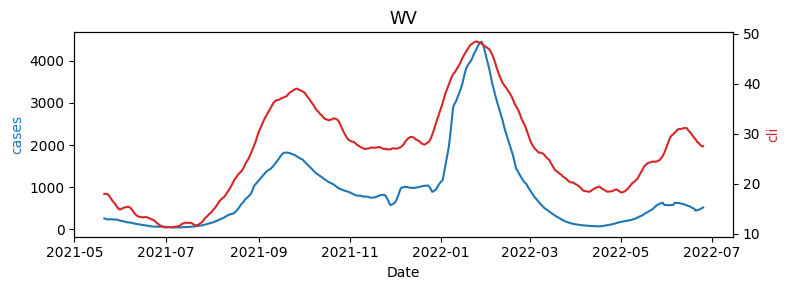

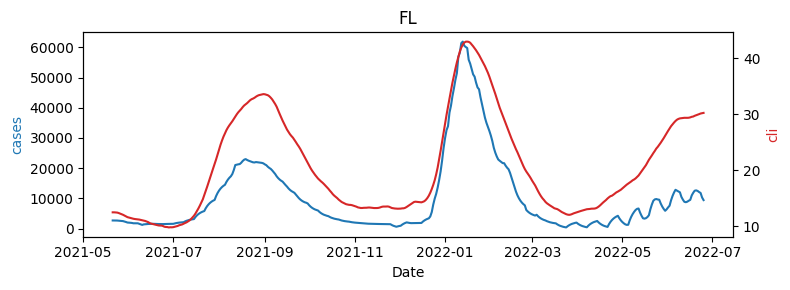

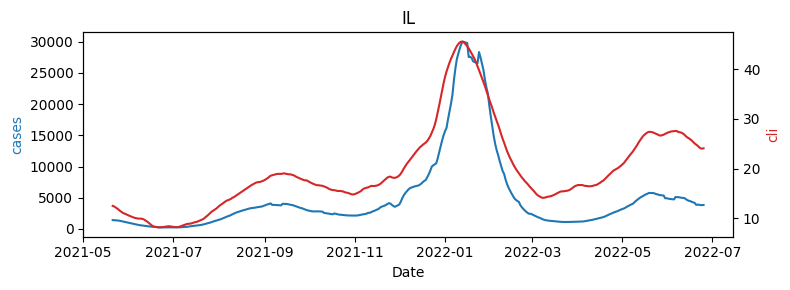

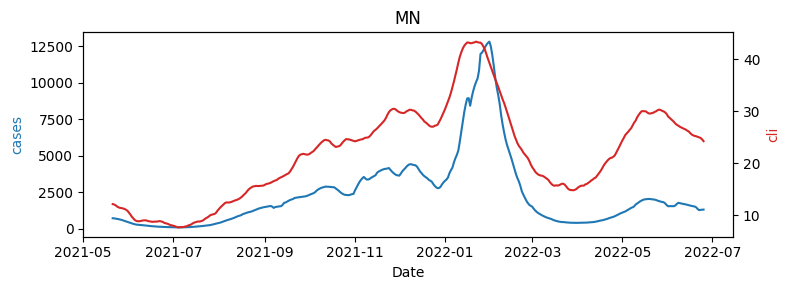

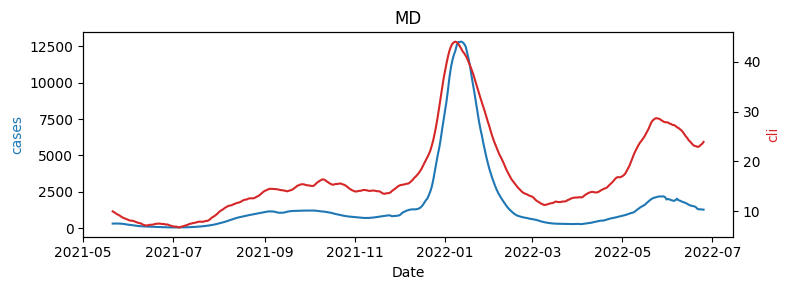

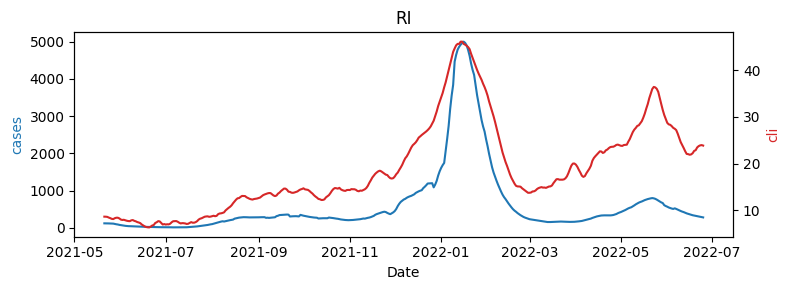

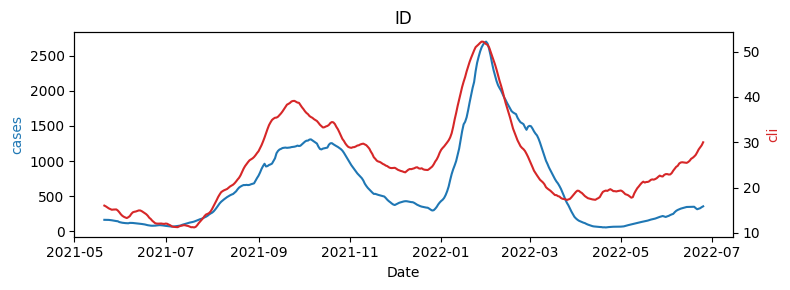

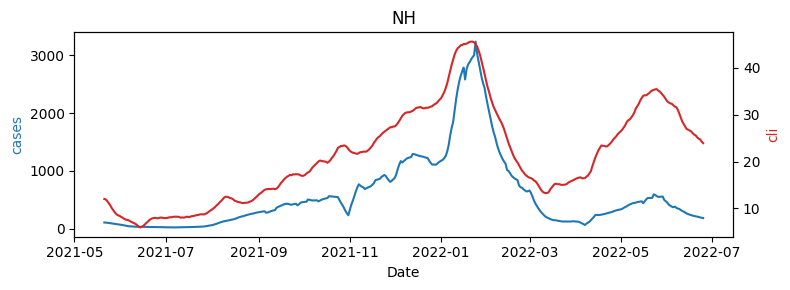

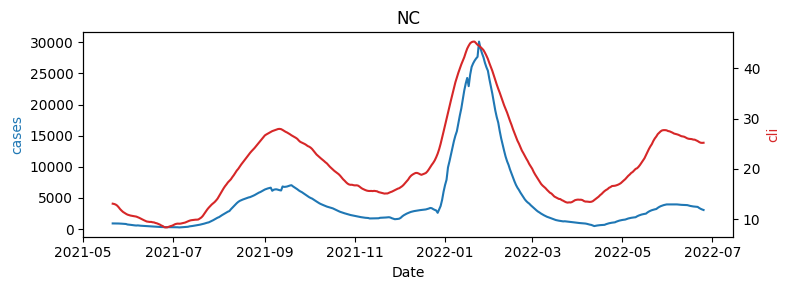

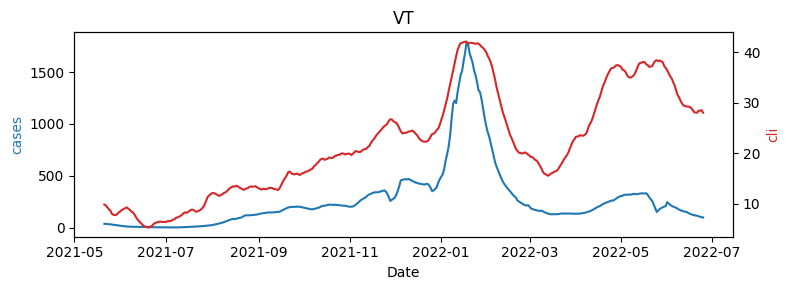

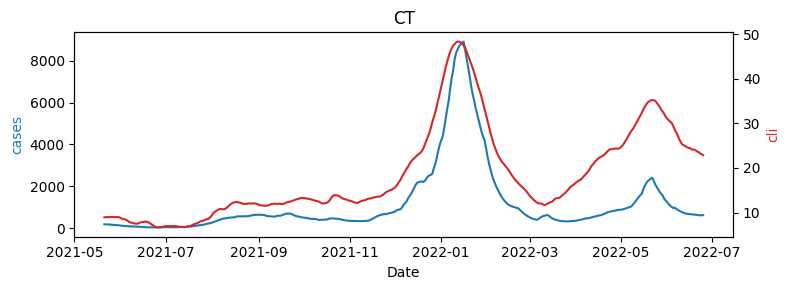

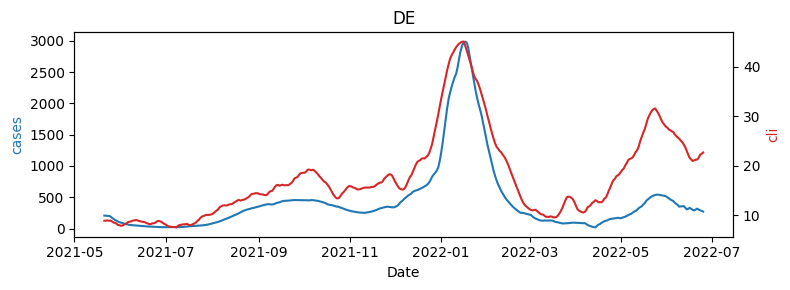

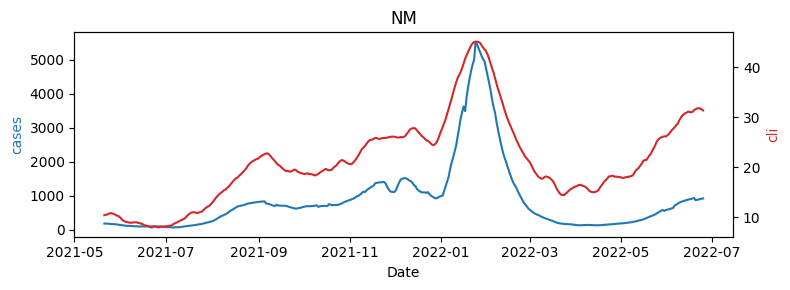

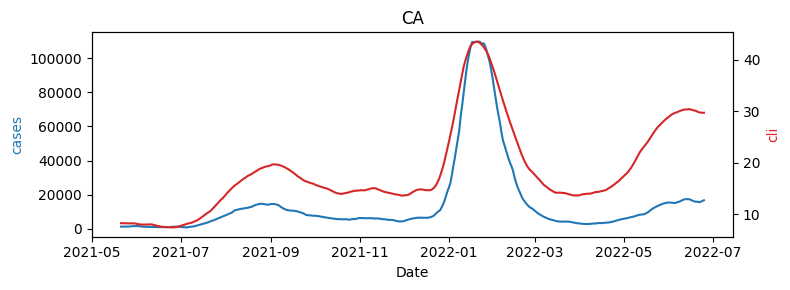

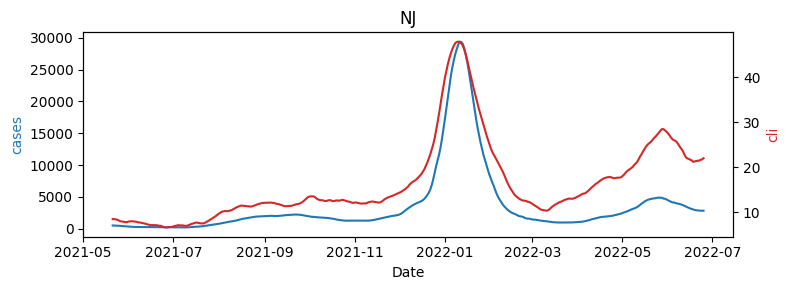

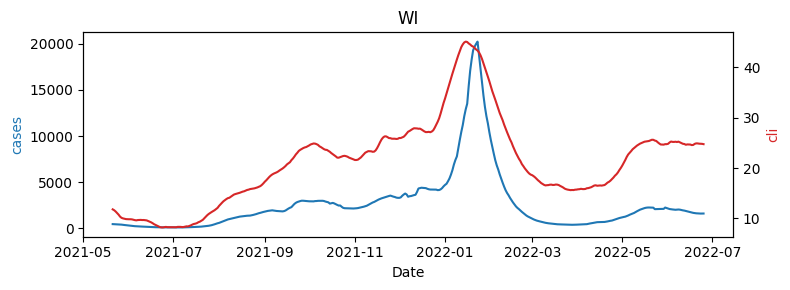

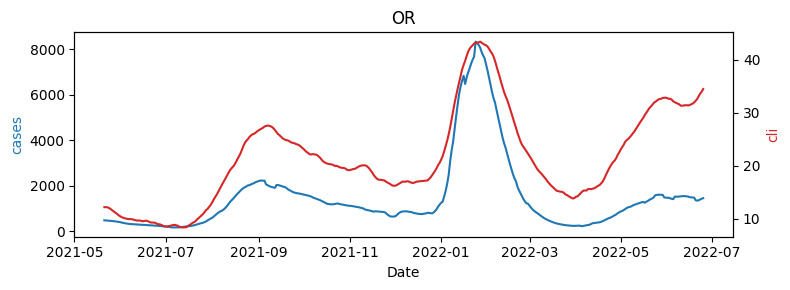

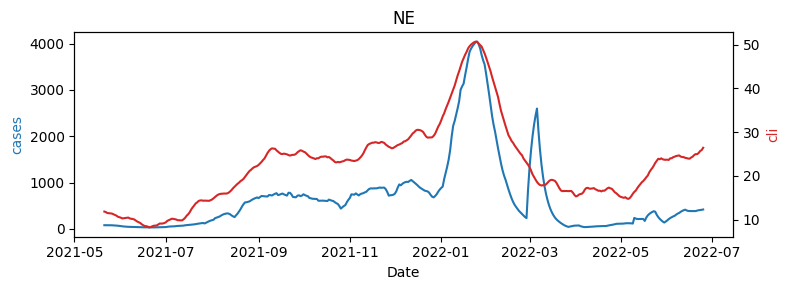

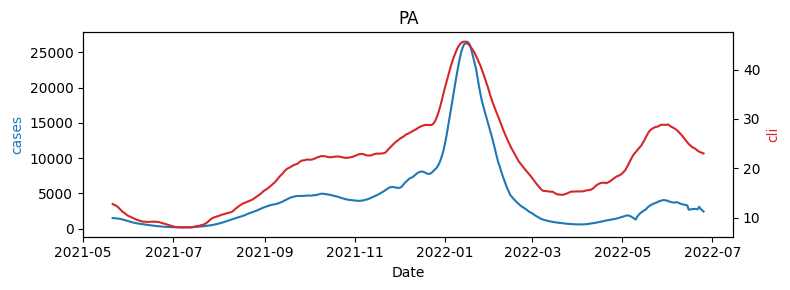

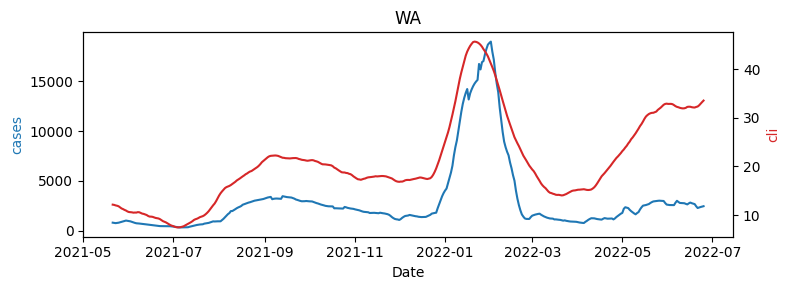

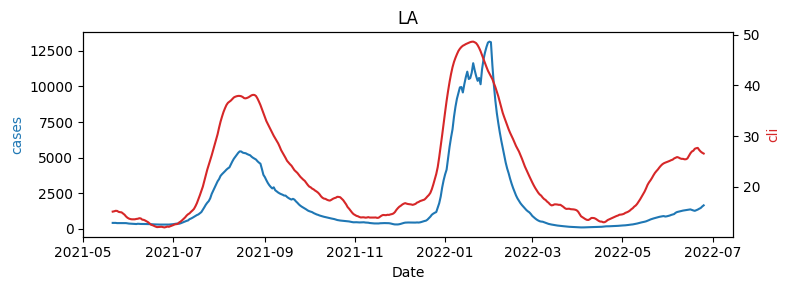

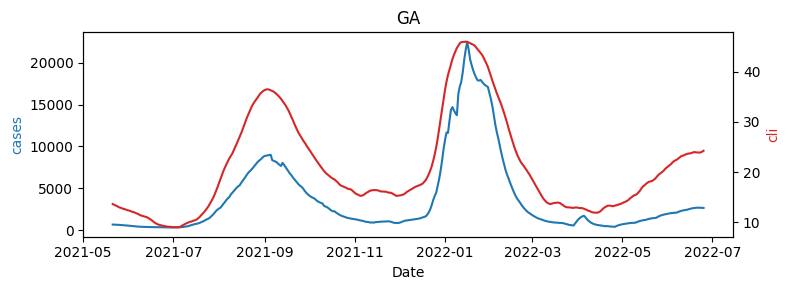

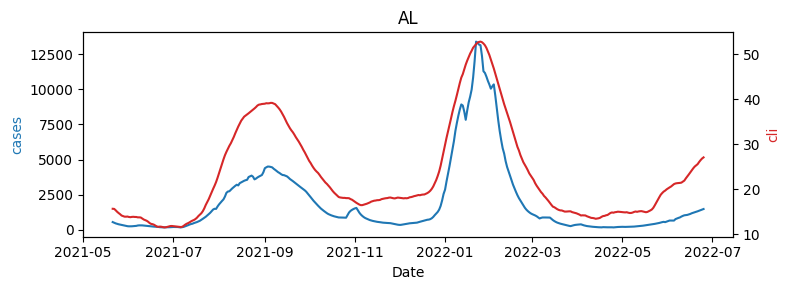

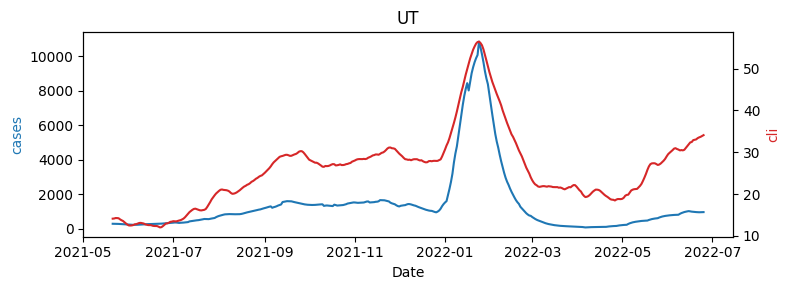

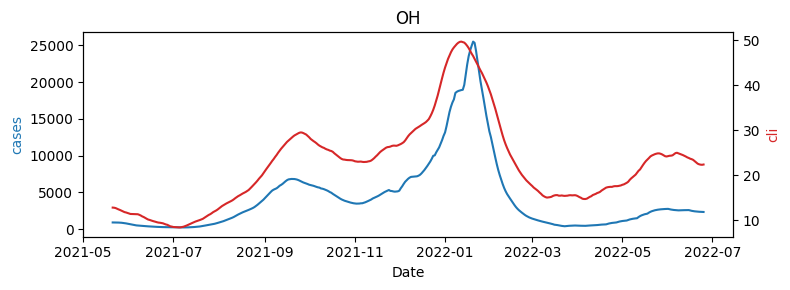

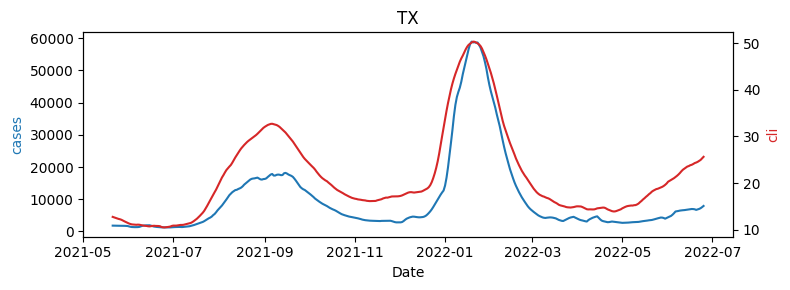

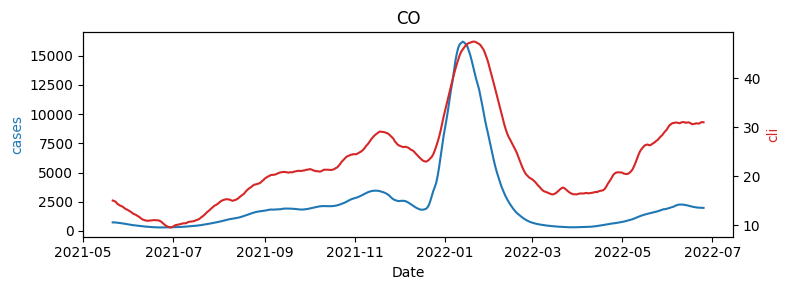

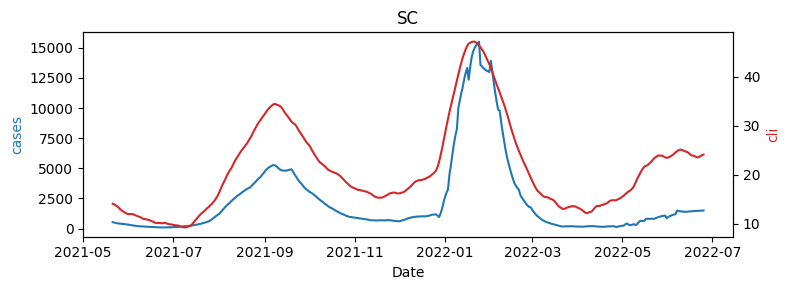

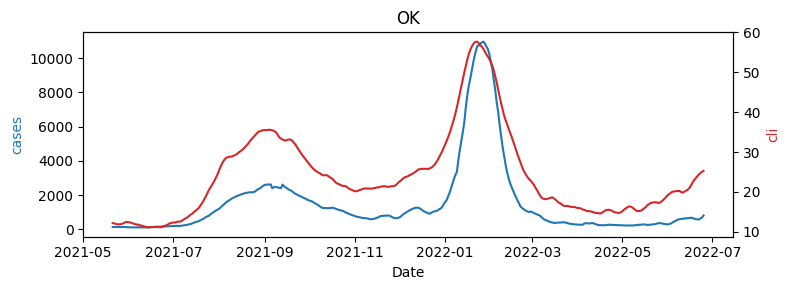

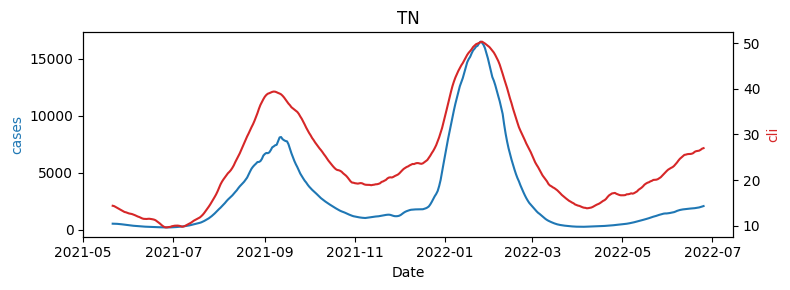

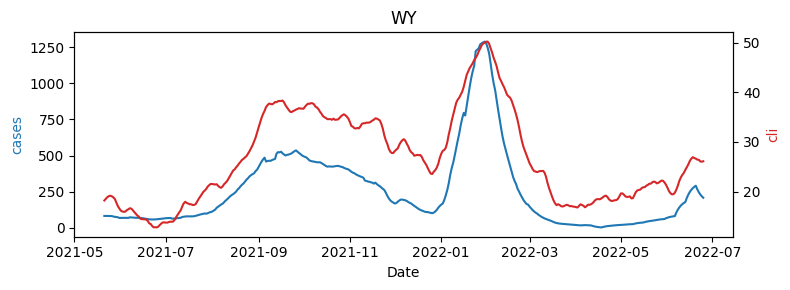

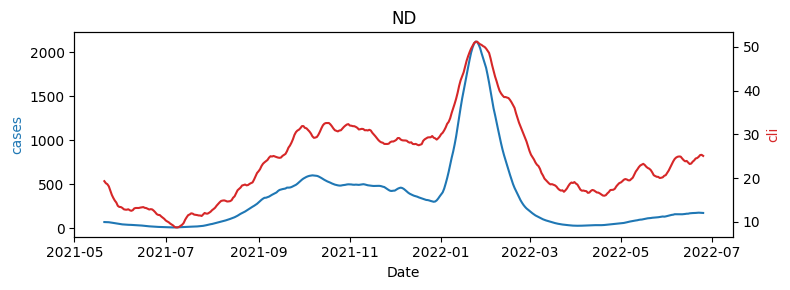

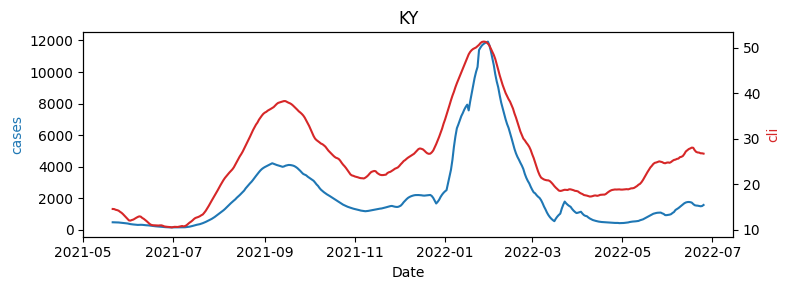

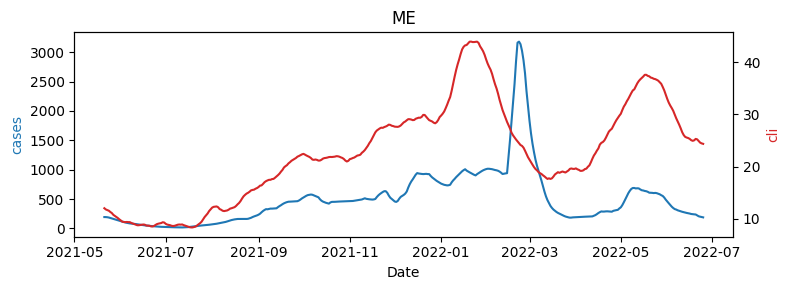

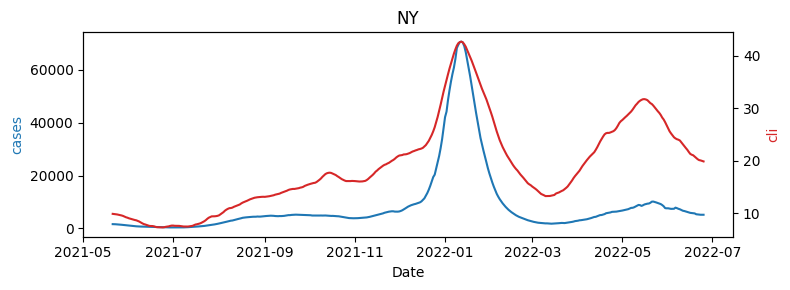

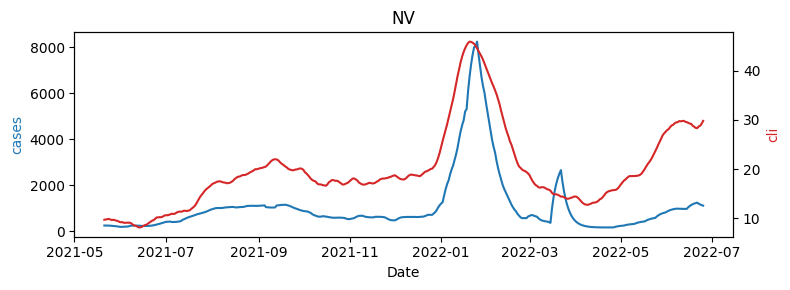

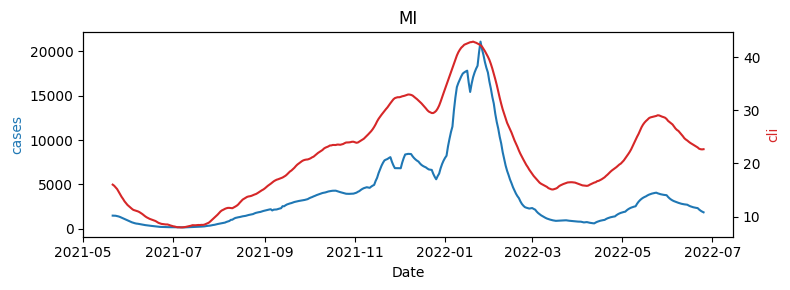

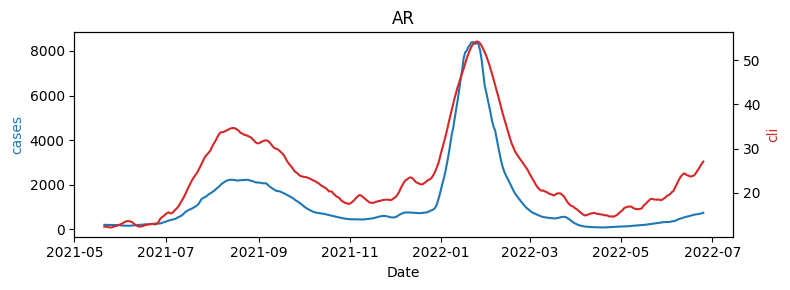

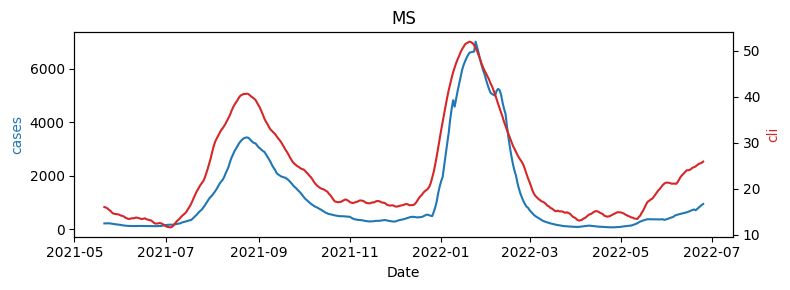

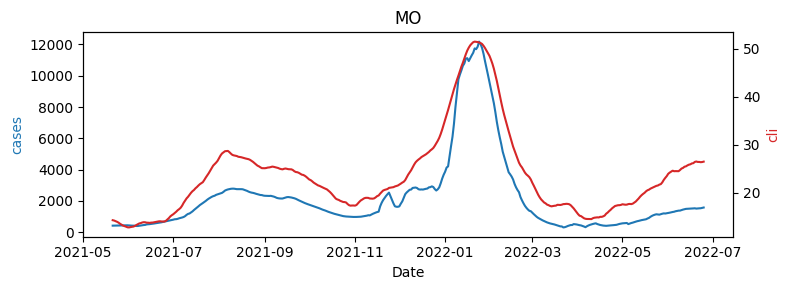

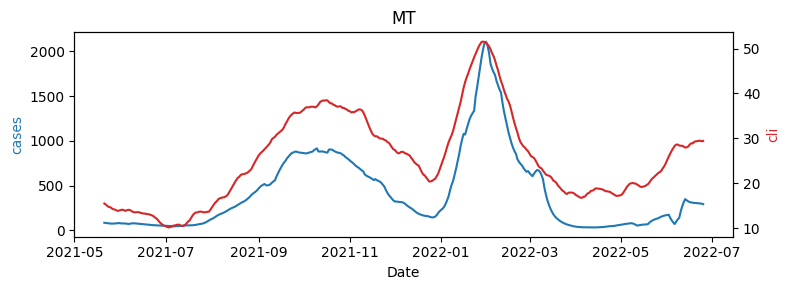

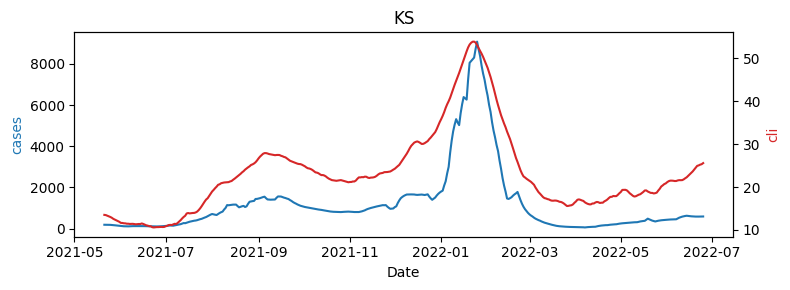

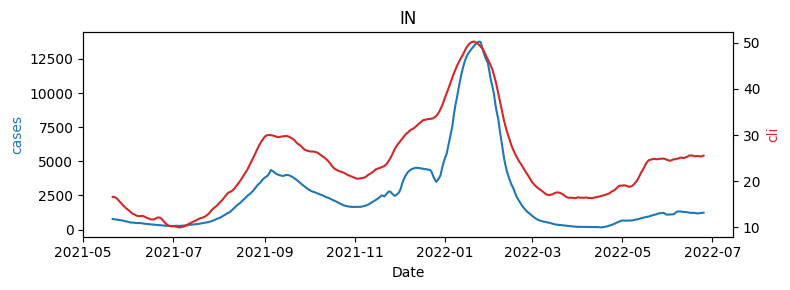

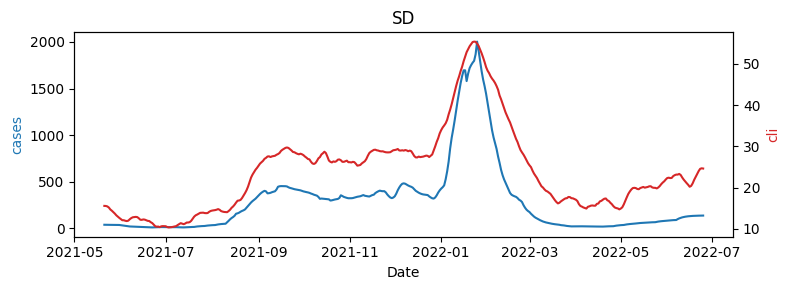

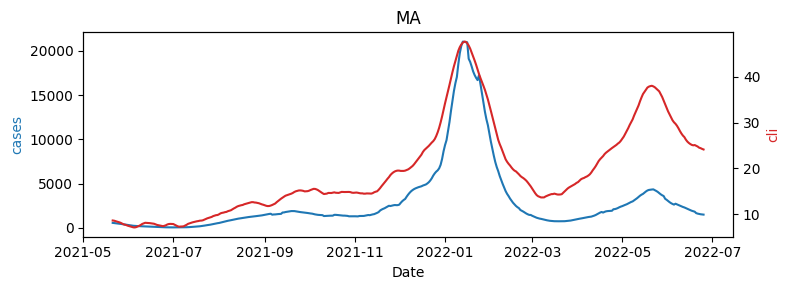

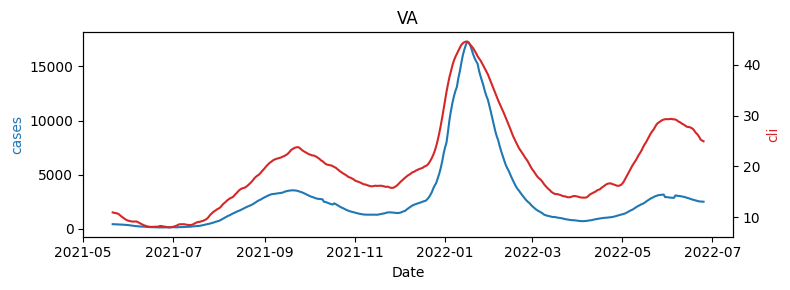

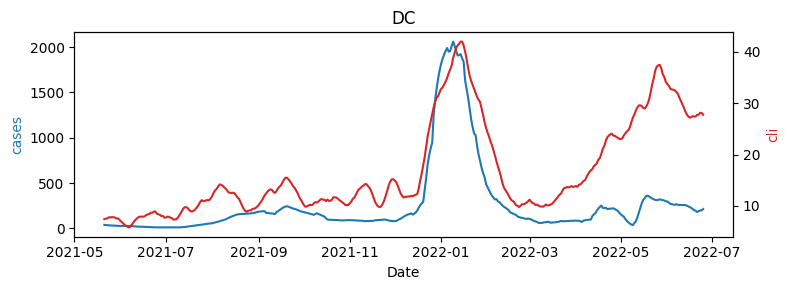

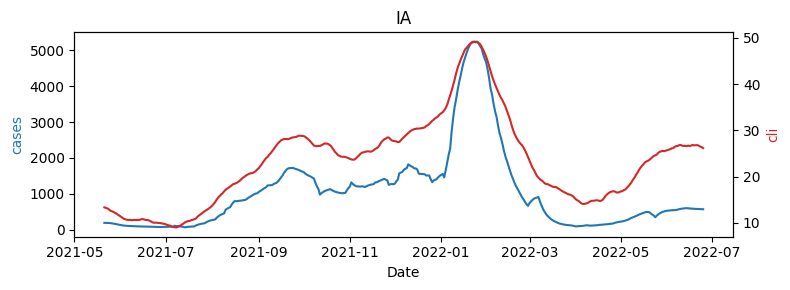

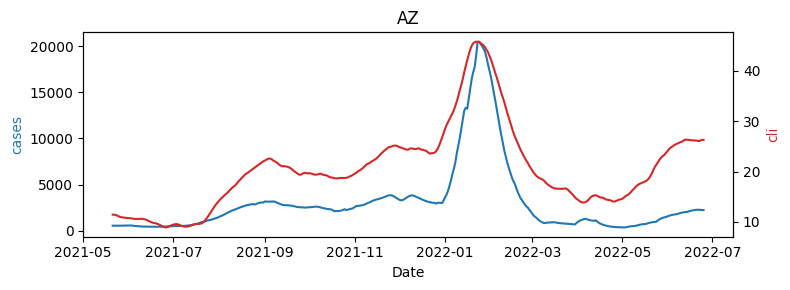

In [37]:
# Data plot inspection

def plot_cases_vs_var_old(data_dict, dates, series_index):
    var = ["cases", "cli", "cli_cmnt", "doctor visits", "mask", "si"]
    for state in data_dict.keys():
        plt.figure(figsize=(8, 3))
        plt.plot(dates, data_dict[state][0], label='Cases')
        plt.plot(dates, data_dict[state][series_index], label = f"{var[series_index]}")
        
        plt.title(f"{state.upper()}")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        #plt.semilogy()
        plt.tight_layout()
        plt.show()


def plot_cases_vs_var(data_dict, dates, series_index):
    var = ["cases", "cli", "cli_cmnt", "doctor visits", "mask", "event indoor", "work outside", "public transit", "si"]
    for state in data_dict.keys():
        fig, ax1 = plt.subplots(figsize=(8, 3))

        # Left Y-Axis (ax1)
        color_a = 'tab:blue'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('cases', color=color_a)
        # Plot the first series on ax1
        line1 = ax1.plot(dates, data_dict[state][0], label='Cases', color=color_a)
        #ax1.tick_params(axis='y', labelcolor=color_a)

        # Right Y-Axis (ax2)
        ax2 = ax1.twinx()  # Use the twinx() method to create a second axes object with the same X-axis
        color_b = 'tab:red'
        ax2.set_ylabel(f"{var[series_index]}", color=color_b)
        # Plot the second series on ax2
        line2 = ax2.plot(dates, data_dict[state][series_index], label = f"{var[series_index]}", color=color_b)
        #ax2.tick_params(axis='y', labelcolor=color_b)

        plt.title(f"{state.upper()}")
        # Combine the line objects from both axes to create a single legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        #ax1.legend(lines, labels, loc='upper left')
        # Adjust layout 
        fig.tight_layout()  

        plt.show()


plot_cases_vs_var(smoothed_data, dates, 1)

